In [11]:
# ============================================================
# MODEL 2: Main model + repeated seller count
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import patsy
from statsmodels.stats.outliers_influence import variance_inflation_factor

from color_mapping import clean_color_column
from country_mapping import clean_country_column


# ============================================================
# 1. Load data
# ============================================================

file_path = r"C:\Users\nikin\Desktop\IphonesFinal.xlsx"

df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

print("Original dataset shape:", df.shape)
print("\nOriginal columns:")
print(df.columns)


# ============================================================
# 2. Cleaning functions
# ============================================================

def clean_price(value):
    if pd.isna(value):
        return np.nan

    value = (
        str(value)
        .replace("EUR", "")
        .replace("€", "")
        .replace(".", "")
        .replace(",", ".")
        .strip()
    )

    if value in ["", "N/A", "nan", "None"]:
        return np.nan

    return pd.to_numeric(value, errors="coerce")


def clean_seller_rating(value):
    if pd.isna(value):
        return np.nan

    value_str = str(value).strip()

    if value_str == "" or value_str.upper() == "N/A":
        return np.nan

    has_percent = "%" in value_str

    value_str = (
        value_str
        .replace("%", "")
        .replace(",", ".")
        .strip()
    )

    rating = pd.to_numeric(value_str, errors="coerce")

    if pd.isna(rating):
        return np.nan

    # If rating is written as 0.99, convert to 99
    if not has_percent and rating <= 1:
        rating = rating * 100

    return rating


def clean_seller_total_sales(value):
    if pd.isna(value):
        return np.nan

    value = (
        str(value)
        .replace(".", "")
        .replace(",", ".")
        .replace("+", "")
        .strip()
    )

    if value in ["", "N/A", "nan", "None"]:
        return np.nan

    return pd.to_numeric(value, errors="coerce")


def clean_text(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "" or value.upper() == "N/A":
        return np.nan

    return value


# ============================================================
# 3. Basic variable cleaning
# ============================================================

model_df = df.copy()

model_df["price"] = model_df["Preis"].apply(clean_price)

model_df["Farbe_clean"] = clean_color_column(model_df["Farbe"])

model_df["country_group"] = clean_country_column(model_df["Herkunftsland"])

model_df["Zustand_clean"] = model_df["Zustand"].apply(clean_text).str.lower()

model_df["Seller_Type_clean"] = model_df["Seller Type"].apply(clean_text).str.lower()

model_df["Verkaufsart_clean"] = model_df["Verkaufsart"].apply(clean_text).str.lower()

model_df["seller_rating"] = model_df["Seller Rating"].apply(clean_seller_rating)


# ============================================================
# 4. Clean seller total sales column
# ============================================================

possible_sales_cols = [
    col for col in model_df.columns
    if "verkauften" in col.lower() or "artikel" in col.lower()
]

print("\nFound seller sales columns:")
print(possible_sales_cols)

seller_sales_col = possible_sales_cols[0]

model_df["seller_total_sales"] = model_df[seller_sales_col].apply(clean_seller_total_sales)

model_df["log_seller_total_sales"] = np.log1p(model_df["seller_total_sales"])


# ============================================================
# 5. Standardize categorical values
# ============================================================

model_df["Zustand_clean"] = model_df["Zustand_clean"].replace({
    "neu": "neu",
    "gebraucht": "gebraucht",
    "refurbished": "refurbished",
    "generalüberholt": "refurbished",
    "generaluberholt": "refurbished"
})

model_df["Seller_Type_clean"] = model_df["Seller_Type_clean"].replace({
    "privat": "privat",
    "private": "privat",
    "gewerblich": "gewerblich",
    "commercial": "gewerblich"
})

model_df["Verkaufsart_clean"] = model_df["Verkaufsart_clean"].replace({
    "sofortkauf": "sofortkauf",
    "auktion": "auktion",
    "sofortkauf + pr": "sofortkauf + pr",
    "sofortkauf + preisvorschlag": "sofortkauf + pr"
})


# ============================================================
# 6. Seller rating missing-value handling
# ============================================================

# Remove suspicious very low seller ratings
model_df.loc[model_df["seller_rating"] < 80, "seller_rating"] = np.nan

model_df["seller_rating_missing"] = model_df["seller_rating"].isna().astype(int)

model_df["seller_rating_filled"] = model_df["seller_rating"].fillna(
    model_df["seller_rating"].mean()
)


# ============================================================
# 7. NEW VARIABLE: repeated seller count
# ============================================================

# Clean seller name first
model_df["seller_name_clean"] = (
    model_df["Shop/Seller"]
    .astype(str)
    .str.strip()
    .str.lower()
)

model_df.loc[
    model_df["seller_name_clean"].isin(["", "nan", "none", "n/a"]),
    "seller_name_clean"
] = np.nan

# Count how often each seller appears in this dataset
model_df["seller_listing_count"] = (
    model_df.groupby("seller_name_clean")["seller_name_clean"]
    .transform("count")
)

# Log transformation because some sellers may appear much more often than others
model_df["log_seller_listing_count"] = np.log1p(model_df["seller_listing_count"])


print("\nSeller listing count summary:")
print(model_df["seller_listing_count"].describe())

print("\nMost repeated sellers:")
print(
    model_df[["seller_name_clean", "seller_listing_count"]]
    .drop_duplicates()
    .sort_values("seller_listing_count", ascending=False)
    .head(20)
)


# ============================================================
# 8. Descriptive checks
# ============================================================

print("\nPrice summary:")
print(model_df["price"].describe())

print("\nSeller rating summary:")
print(model_df["seller_rating_filled"].describe())

print("\nMissing seller rating dummy:")
print(model_df["seller_rating_missing"].value_counts(dropna=False))

check_cols = [
    "Zustand_clean",
    "Farbe_clean",
    "Seller_Type_clean",
    "country_group",
    "Verkaufsart_clean"
]

for col in check_cols:
    print("\n" + "=" * 50)
    print(col)
    print(model_df[col].value_counts(dropna=False))


# ============================================================
# 9. Build regression dataframe
# ============================================================

regression_df = model_df[
    [
        "price",
        "Zustand_clean",
        "Farbe_clean",
        "Seller_Type_clean",
        "country_group",
        "Verkaufsart_clean",
        "seller_rating_filled",
        "seller_rating_missing",
        "log_seller_total_sales",
        "log_seller_listing_count"
    ]
].copy()

print("\nBefore dropping missing values:", regression_df.shape)

print("\nMissing values before dropna:")
print(regression_df.isna().sum())

regression_df = regression_df.dropna()

print("\nAfter dropping missing values:", regression_df.shape)


# ============================================================
# 10. Run regression model
# ============================================================

formula_repeated_sellers = """
price ~ C(Zustand_clean, Treatment(reference="neu"))
      + C(Farbe_clean, Treatment(reference="schwarz"))
      + C(Seller_Type_clean, Treatment(reference="privat"))
      + C(country_group, Treatment(reference="deutschland"))
      + C(Verkaufsart_clean, Treatment(reference="sofortkauf"))
      + seller_rating_filled
      + seller_rating_missing
      + log_seller_total_sales
      + log_seller_listing_count
"""

main_model_repeated_sellers = smf.ols(
    formula=formula_repeated_sellers,
    data=regression_df
).fit()

print("\n================ MAIN MODEL WITH REPEATED SELLERS ================")
print(main_model_repeated_sellers.summary())


# ============================================================
# 11. Coefficient table
# ============================================================

results_table_repeated_sellers = pd.DataFrame({
    "Variable": main_model_repeated_sellers.params.index,
    "Coefficient": main_model_repeated_sellers.params.values,
    "P-value": main_model_repeated_sellers.pvalues.values
}).sort_values("P-value")

print("\n================ COEFFICIENT TABLE ================")
print(results_table_repeated_sellers)


# ============================================================
# 12. Model quality
# ============================================================

print("\n================ MODEL QUALITY ================")
print("Observations:", int(main_model_repeated_sellers.nobs))
print("R-squared:", round(main_model_repeated_sellers.rsquared, 4))
print("Adjusted R-squared:", round(main_model_repeated_sellers.rsquared_adj, 4))
print("AIC:", round(main_model_repeated_sellers.aic, 4))
print("BIC:", round(main_model_repeated_sellers.bic, 4))


# ============================================================
# 13. VIF check
# ============================================================

y_vif, X_vif = patsy.dmatrices(
    formula_repeated_sellers,
    data=regression_df,
    return_type="dataframe"
)

vif_table = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
}).sort_values("VIF", ascending=False)

print("\n================ VIF TABLE ================")
print(vif_table)


# ============================================================
# 14. Compare with old main model if it exists
# ============================================================

try:
    model_comparison_repeated = pd.DataFrame({
        "Model": [
            "Model 1: Original main model",
            "Model 1B: Main + repeated seller count"
        ],
        "Observations": [
            int(main_model.nobs),
            int(main_model_repeated_sellers.nobs)
        ],
        "R-squared": [
            main_model.rsquared,
            main_model_repeated_sellers.rsquared
        ],
        "Adjusted R-squared": [
            main_model.rsquared_adj,
            main_model_repeated_sellers.rsquared_adj
        ],
        "AIC": [
            main_model.aic,
            main_model_repeated_sellers.aic
        ],
        "BIC": [
            main_model.bic,
            main_model_repeated_sellers.bic
        ]
    })

    model_comparison_repeated[
        ["R-squared", "Adjusted R-squared", "AIC", "BIC"]
    ] = model_comparison_repeated[
        ["R-squared", "Adjusted R-squared", "AIC", "BIC"]
    ].round(4)

    print("\n================ MODEL COMPARISON ================")
    print(model_comparison_repeated)

except NameError:
    print("\nNo previous main_model found, so no model comparison was created.")


# ============================================================
# 15. Save results
# ============================================================

regression_df.to_excel(
    "iphone17_main_model_with_repeated_sellers_cleaned_data.xlsx",
    index=False
)

results_table_repeated_sellers.to_excel(
    "iphone17_main_model_with_repeated_sellers_results.xlsx",
    index=False
)

vif_table.to_excel(
    "iphone17_main_model_with_repeated_sellers_vif.xlsx",
    index=False
)

print("\nSaved files:")
print("iphone17_main_model_with_repeated_sellers_cleaned_data.xlsx")
print("iphone17_main_model_with_repeated_sellers_results.xlsx")
print("iphone17_main_model_with_repeated_sellers_vif.xlsx")

Original dataset shape: (491, 17)

Original columns:
Index(['Preis', 'Verkaufsart', 'Zustand', 'Farbe', 'Batteriezustand',
       'Batterie_Info_Vorhanden', 'Verkauft', 'Verfügbar', 'Herkunftsland',
       'Shop/Seller', 'Seller Rating', 'Seller Type',
       'Zahl der verkauften Artikel', 'log_verkauften', 'URL',
       'anzahl_VerkaeuferAngebote', 'log_VerkaeuferAngebote'],
      dtype='object')

Found seller sales columns:
['Zahl der verkauften Artikel', 'log_verkauften']

Seller listing count summary:
count    490.000000
mean       3.783673
std        4.037419
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       18.000000
Name: seller_listing_count, dtype: float64

Most repeated sellers:
                 seller_name_clean  seller_listing_count
414                         sr_evo                  18.0
367                              h                  13.0
259                 upgrade-cecere                  12.0
197                      boomstore

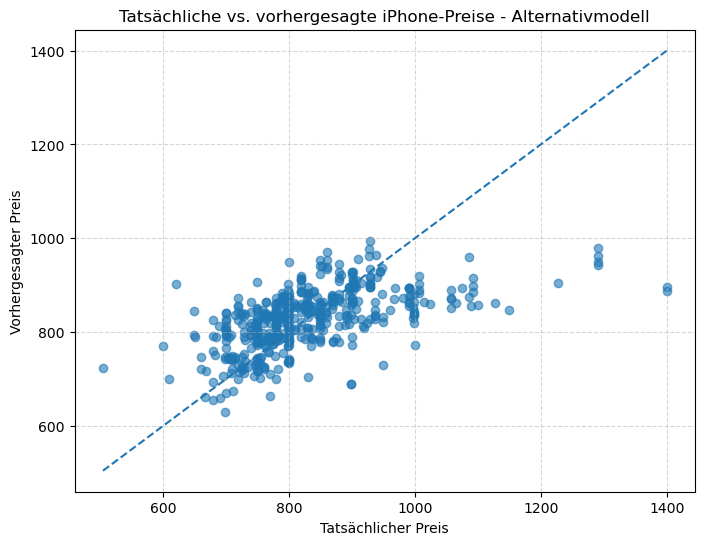

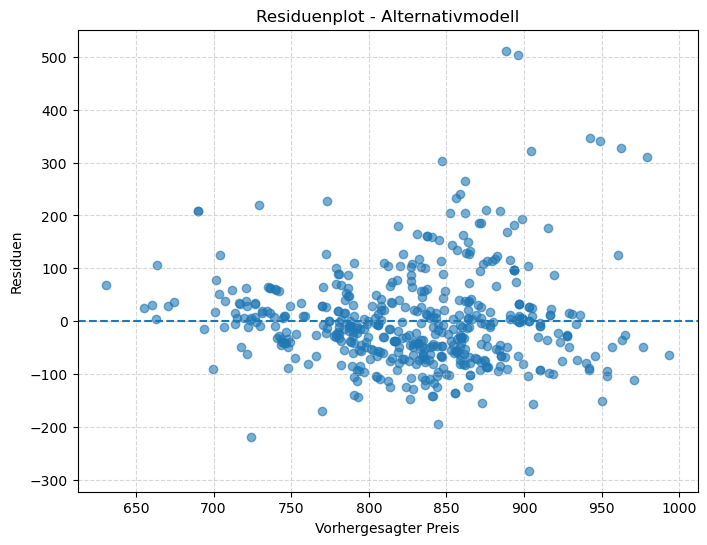

In [12]:
import matplotlib.pyplot as plt

# ============================================================
# PLOTS FOR ALTERNATIVE MODEL: Main model + recurrent sellers
# ============================================================

# Predict prices with the alternative model
regression_df_recurrent = regression_df_recurrent.copy()
regression_df_recurrent["predicted_price_alt"] = recurrent_train_test_model.predict(regression_df_recurrent)
regression_df_recurrent["residual_alt"] = (
    regression_df_recurrent["price"] - regression_df_recurrent["predicted_price_alt"]
)

# ============================================================
# Plot 1: Actual vs Predicted
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(
    regression_df_recurrent["price"],
    regression_df_recurrent["predicted_price_alt"],
    alpha=0.6
)

min_price = min(
    regression_df_recurrent["price"].min(),
    regression_df_recurrent["predicted_price_alt"].min()
)

max_price = max(
    regression_df_recurrent["price"].max(),
    regression_df_recurrent["predicted_price_alt"].max()
)

plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")

plt.xlabel("Tatsächlicher Preis")
plt.ylabel("Vorhergesagter Preis")
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("Tatsächliche vs. vorhergesagte iPhone-Preise - Alternativmodell")

plt.show()


# ============================================================
# Plot 2: Residual Plot
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(
    regression_df_recurrent["predicted_price_alt"],
    regression_df_recurrent["residual_alt"],
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.xlabel("Vorhergesagter Preis")
plt.grid(True, linestyle="--", alpha=0.5)   
plt.ylabel("Residuen")
plt.title("Residuenplot - Alternativmodell")

plt.show()